In [4]:
import pandas as pd

In [5]:
df=pd.read_csv("/content/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125.0,212,0,1.0,168.0,0,1.0,2.0,2,3,0
1,53,1,0,140.0,203,1,0.0,155.0,1,3.1,0.0,0,3,0
2,70,1,0,145.0,174,0,1.0,125.0,1,2.6,0.0,0,3,0
3,61,1,0,148.0,203,0,1.0,161.0,0,0.0,2.0,1,3,0
4,62,0,0,138.0,294,1,NaN,106.0,0,1.9,1.0,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140.0,221,0,1.0,164.0,1,0.0,2.0,0,2,1
1021,60,1,0,125.0,258,0,0.0,141.0,1,2.8,1.0,1,3,0
1022,47,1,0,110.0,275,0,0.0,118.0,1,1.0,1.0,1,2,0
1023,50,0,0,110.0,254,0,0.0,159.0,0,0.0,2.0,0,2,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1017 non-null   float64
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1018 non-null   float64
 7   thalach   1018 non-null   float64
 8   exang     1025 non-null   int64  
 9   oldpeak   1021 non-null   float64
 10  slope     1019 non-null   float64
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(5), int64(9)
memory usage: 112.2 KB


In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,8
chol,0
fbs,0
restecg,7
thalach,7
exang,0
oldpeak,4


In [8]:
df.isnull().sum().sum()

np.int64(32)

In [9]:
x=df.iloc[:,:13]
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125.0,212,0,1.0,168.0,0,1.0,2.0,2,3
1,53,1,0,140.0,203,1,0.0,155.0,1,3.1,0.0,0,3
2,70,1,0,145.0,174,0,1.0,125.0,1,2.6,0.0,0,3
3,61,1,0,148.0,203,0,1.0,161.0,0,0.0,2.0,1,3
4,62,0,0,138.0,294,1,NaN,106.0,0,1.9,1.0,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140.0,221,0,1.0,164.0,1,0.0,2.0,0,2
1021,60,1,0,125.0,258,0,0.0,141.0,1,2.8,1.0,1,3
1022,47,1,0,110.0,275,0,0.0,118.0,1,1.0,1.0,1,2
1023,50,0,0,110.0,254,0,0.0,159.0,0,0.0,2.0,0,2


In [10]:
y=df.target
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
1020,1
1021,0
1022,0
1023,1


In [11]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
xtrain = xtrain.fillna(xtrain.median())
xtest = xtest.fillna(xtrain.median())

In [13]:
from sklearn.preprocessing import  StandardScaler
scaler=StandardScaler()
scaler.fit(xtrain)
xtrain=scaler.transform(xtrain)
xtrain

array([[-0.58584022,  0.65465367,  1.008275  , ...,  1.01241566,
         2.17169136, -0.54519316],
       [ 1.05147737, -1.52752523, -0.91672034, ...,  1.01241566,
        -0.7254674 , -0.54519316],
       [-0.04006769, -1.52752523,  1.008275  , ...,  1.01241566,
        -0.7254674 , -0.54519316],
       ...,
       [-0.36753121,  0.65465367, -0.91672034, ...,  1.01241566,
        -0.7254674 ,  1.11057867],
       [-1.24076726,  0.65465367, -0.91672034, ...,  1.01241566,
        -0.7254674 ,  1.11057867],
       [-0.2583767 ,  0.65465367, -0.91672034, ...,  1.01241566,
         0.24025219, -0.54519316]])

In [14]:
xtest=scaler.transform(xtest)
xtest

array([[ 0.83316836, -1.52752523, -0.91672034, ...,  1.01241566,
        -0.7254674 , -0.54519316],
       [-0.1492222 , -1.52752523,  1.008275  , ...,  1.01241566,
        -0.7254674 , -3.85673683],
       [ 0.06908682,  0.65465367, -0.91672034, ..., -0.63476855,
         0.24025219,  1.11057867],
       ...,
       [-1.13161275,  0.65465367,  1.008275  , ...,  1.01241566,
        -0.7254674 , -0.54519316],
       [ 0.72401385,  0.65465367, -0.91672034, ...,  1.01241566,
         0.24025219,  1.11057867],
       [ 0.39655033,  0.65465367,  1.008275  , ..., -0.63476855,
         0.24025219,  1.11057867]])

In [15]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=7)
model

KNeighborsClassifier(n_neighbors=7)

In [16]:
model.fit(xtrain,ytrain)

KNeighborsClassifier(n_neighbors=7)

In [17]:
ypred=model.predict(xtest)
ypred

array([1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0])

In [18]:
ytest.values

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0])

In [19]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(ytest,ypred)
cm

array([[77, 25],
       [11, 92]])

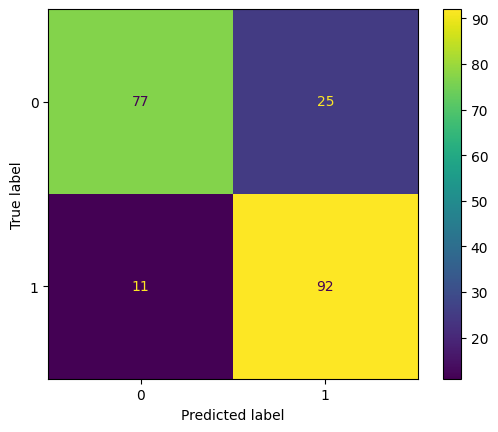

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
cmd=ConfusionMatrixDisplay(cm)
cmd.plot()

In [21]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(ytest,ypred)
acc

0.824390243902439

In [22]:
from sklearn.metrics import  recall_score
recall=recall_score(ytest,ypred)
recall

0.8932038834951457

In [23]:
from sklearn.metrics import precision_score
score=precision_score(ytest,ypred)
score

0.7863247863247863

In [24]:
from sklearn.metrics import f1_score
score1=f1_score(ytest,ypred)
score1

0.8363636363636363